In [1]:
! pip install lxml

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------- -------------------------- 1.3/4.0 MB 9.3 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 8.8 MB/s eta 0:00:00


In [5]:
! pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------- ----------------------------- 0.8/3.0 MB 6.7 MB/s eta 0:00:01
     ------------------------------- -------- 2.4/3.0 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 7.3 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 9.8 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=3a2b22eb156f7e20f0de

In [8]:
! pip install fredapi 


In [84]:
! pip install bokeh 

In [95]:
! pip install bokeh 

In [ ]:
import matplotlib.pyplot as plt 
import yfinance as yf
import os
from datetime import datetime
import pandas as pd
from fredapi import Fred
from datetime import datetime
import requests
import numpy as np 
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, Legend, LegendItem
from bokeh.palettes import Category10, Category20
import numpy as np
import matplotlib.pyplot as plt 


## Introduction 

Monetary liquidity is often cited as a key driver of financial markets, yet its short-term influence on equity returns remains unclear. This project builds a data-driven liquidity index using major Federal Reserve series and evaluates whether it helps predict the daily direction of the S&P 500. Using Ridge regression with time-series cross-validation, I focus on variables whose effects are stable across different periods. The resulting index is then backtested to assess its economic relevance and its ability to improve market-timing performance.

# The dataset 

## Collecting the data 

In [4]:
df_snp = yf.Ticker("^GSPC").history(period="15y")[['Close']]
print(df_snp.head())

                                 Close
Date                                  
2010-11-15 00:00:00-05:00  1197.750000
2010-11-16 00:00:00-05:00  1178.339966
2010-11-17 00:00:00-05:00  1178.589966
2010-11-18 00:00:00-05:00  1196.689941
2010-11-19 00:00:00-05:00  1199.729980


In [ ]:
# ========== SNP ==========

# simple return: r_t = (P_t / P_{t-1}) - 1
spx_ret = df_snp.pct_change()

spx_ret_next = spx_ret.shift(-1) # shifted
spx_ret_next.name = "RET_SPX_NEXT_DAY"

In [ ]:
# ========== CB data ==========

FRED_API_KEY = "0468f56987a719defdb96dc638e6e129"

START_DATE = "2010-01-01"
END_DATE = None  # None = up to today


FRED_SERIES = {
    # -----------------------------
    # H.4.1 – Fed Balance Sheet
    # -----------------------------
    "reserves_balance": "RESBALNS",
    "reserves_total": "TOTRESNS",
    "reserves_required": "REQRESNS",
    "reserves_excess": "EXCSRESNS",

    "reverse_repos_on": "RRPONTSYD",

    "fed_total_assets": "WALCL",
    "securities_held_outright": "WSHOSHO",
    "treasuries_held": "WSHOTSL",
    "mbs_held": "WSHOMCB",

    # -----------------------------
    # H.6 – Money Stock Measures
    # -----------------------------
    "m1": "M1SL",
    "m2": "M2SL",
    "m1_nsa": "M1NS",
    "m2_nsa": "M2NS",

    "monetary_base": "BOGMBASE",
    "monetary_base_adjusted": "AMBSL",

    "savings_deposits": "SAVINGS",
    "demand_deposits": "DEMDEPSL",

    "velocity_m1": "M1V",
    "velocity_m2": "M2V",

    # -----------------------------
    # H.15 – Interest Rates
    # -----------------------------
    "fed_funds": "FEDFUNDS",
    "iorb": "IORB",
    "ioer" : "IOER",
    "sofr": "SOFR",
    "effr" : "EFFR",

    "t1m": "DGS1MO",
    "t3m": "DGS3MO",
    "t6m": "DGS6MO",
    "t1y": "DGS1",
    "t2y": "DGS2",
    "t5y": "DGS5",
    "t10y": "DGS10",
    "t30y": "DGS30",

    "aaa_yield": "AAA",
    "baa_yield": "BAA",
    "hy_spread": "BAMLH0A0HYM2",
    "ig_spread": "BAMLC0A0CM",

    # -----------------------------
    # Z.1 – Financial Accounts
    # -----------------------------
    "household_net_worth": "TNWBSHNO",

    "household_debt": "CMDEBT",
    "corporate_debt": "NCBDBIQ027S",
    "government_debt": "FGSDODNS",

    "bank_credit": "TOTBKCR",
    "ci_loans": "BUSLOANS",
}


FRED_RELEASE_IDS = {
    "H41": 20,   # H.4.1 Factors Affecting Reserve Balances
    "H6": 21,    # H.6 Money Stock Measures
    "H15": 18,   # H.15 Selected Interest Rates
    "Z1": 52,    # Z.1 Financial Accounts of the US
}


def init_fred(api_key: str = None) -> Fred:
    """Initialize FRED client."""
    if api_key is None:
        raise ValueError(
            "FRED_API_KEY not found. Set it as an environment variable or "
            "hard-code it in the script."
        )
    return Fred(api_key=api_key)


def download_fred_series(fred: Fred,
                         series_dict: dict,
                         start: str | None = None,
                         end: str | None = None) -> pd.DataFrame:
    """
    Download several FRED series and return a single DataFrame.

    index: Date
    columns: keys of series_dict
    """
    all_series = {}

    for name, series_id in series_dict.items():
        print(f"Downloading FRED series {series_id} ({name})...")
        s = fred.get_series(series_id, observation_start=start, observation_end=end)
        s.name = name
        all_series[name] = s

    df = pd.DataFrame(all_series)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df


def get_release_dates_for_id(release_id: int,
                             api_key: str,
                             start: str | None = None,
                             end: str | None = None) -> pd.Series:
    """
    Return a pandas.Series of release dates (Timestamp) for a given FRED release_id.
    Optional start/end to restrict the range.
    """
    url = "https://api.stlouisfed.org/fred/release/dates"
    params = {
        "api_key": api_key,
        "file_type": "json",
        "release_id": release_id,
        "sort_order": "asc",
        "limit": 1000,
    }

    dates = []
    offset = 0

    while True:
        params["offset"] = offset
        r = requests.get(url, params=params)
        r.raise_for_status()
        chunk = r.json().get("release_dates", [])
        if not chunk:
            break
        dates.extend([d["date"] for d in chunk])
        offset += len(chunk)
        if len(chunk) < params["limit"]:
            break

    s = pd.to_datetime(pd.Series(dates).drop_duplicates())
    if start is not None:
        s = s[s >= pd.to_datetime(start)]
    if end is not None:
        s = s[s <= pd.to_datetime(end)]
    return s.sort_values().reset_index(drop=True)


def build_announcement_calendar(api_key: str,
                                start: str | None = None,
                                end: str | None = None) -> pd.DataFrame:
    """
    Build a daily DataFrame with:

      index: daily dates
      columns:
        - is_H41_release, is_H6_release, is_H15_release, is_Z1_release
        - announced_releases: human-readable text
    """
    h41_dates = get_release_dates_for_id(FRED_RELEASE_IDS["H41"], api_key, start, end)
    h6_dates  = get_release_dates_for_id(FRED_RELEASE_IDS["H6"], api_key, start, end)
    h15_dates = get_release_dates_for_id(FRED_RELEASE_IDS["H15"], api_key, start, end)
    z1_dates  = get_release_dates_for_id(FRED_RELEASE_IDS["Z1"], api_key, start, end)

    if start is None:
        start = min(h41_dates.min(), h6_dates.min(), h15_dates.min(), z1_dates.min())
    if end is None:
        end = datetime.today().strftime("%Y-%m-%d")

    idx = pd.date_range(start=start, end=end, freq="D")
    cal = pd.DataFrame(index=idx)

    cal["is_H41_release"] = cal.index.isin(h41_dates)
    cal["is_H6_release"] = cal.index.isin(h6_dates)
    cal["is_H15_release"] = cal.index.isin(h15_dates)
    cal["is_Z1_release"] = cal.index.isin(z1_dates)

    def summarize(row):
        announced = []
        if row["is_H41_release"]:
            announced.append("H.4.1 (Fed balance sheet / reserves)")
        if row["is_H6_release"]:
            announced.append("H.6 (Money stock)")
        if row["is_H15_release"]:
            announced.append("H.15 (Interest rates)")
        if row["is_Z1_release"]:
            announced.append("Z.1 (Financial accounts)")
        return ", ".join(announced) if announced else ""

    cal["announced_releases"] = cal.apply(summarize, axis=1)

    return cal


fred = init_fred(FRED_API_KEY)
df_fed = download_fred_series(fred, FRED_SERIES, start=START_DATE, end=END_DATE)

df_fed_daily = df_fed.asfreq("D").ffill()
calendar = build_announcement_calendar(FRED_API_KEY, start=START_DATE, end=END_DATE)
df_full = df_fed_daily.join(calendar, how="left")

print(df_full.head())


            reserves_balance  reserves_total  reserves_required  \
2010-01-01          1070.701          1112.4             66.575   
2010-01-02          1070.701          1112.4             66.575   
2010-01-03          1070.701          1112.4             66.575   
2010-01-04          1070.701          1112.4             66.575   
2010-01-05          1070.701          1112.4             66.575   

            reserves_excess  reverse_repos_on  fed_total_assets  \
2010-01-01        1045801.0               NaN               NaN   
2010-01-02        1045801.0               NaN               NaN   
2010-01-03        1045801.0               NaN               NaN   
2010-01-04        1045801.0               NaN               NaN   
2010-01-05        1045801.0               NaN               NaN   

            securities_held_outright  treasuries_held  mbs_held      m1  ...  \
2010-01-01                       NaN              NaN       NaN  1674.7  ...   
2010-01-02                       N

## Data cleaning 

- March 15th 2020 : Fed officialy set the reserve requirement ratio to 0% across all banks 
--> reserves_balance and reserves_excess flat afterwards : we drop them and keep reserves_total and reserves_required as a dummy variable coding regime shift <br>
- reverse_repos_on : introduced in 2013 : we accept 0 before 2013 <br>
- Monetary_base_adjusted flat after 2020 : we drop it and use moneatary_base instead <br> 
- April 2020 : distinction between saving_deposits and transaction deposits eliminated : we drop savings_deposits and keep demand_deposits
- IORB starts 2021 : we use IOER before 
- SOFR stats 2018 : we use EFFR before 

In [6]:
df_full['sofr'] = df_full['sofr'].fillna(df_full['effr'])
df_full['iorb'] = df_full['iorb'].fillna(df_full['effr'])
df_full['reserves_required'] = df_full['reserves_required'].apply(lambda x : 1 if x != 0 else 0) # dummy for regime change 

In [ ]:
# ========== clean variables ==========

# Quantity of money / liquidity 
LIQ_MONEY_VARS = [
    "m1",                 # M1SL
    "m2",                 # M2SL
    "monetary_base",      # BOGMBASE
    "demand_deposits",    # DEMDEPSL
]

# Fed balance sheet / market liquidity
LIQ_BALANCE_SHEET_VARS = [
    "reserves_total",     # TOTRESNS
    "reserves_required",   # dummy for regime change 
    "reverse_repos_on",   # RRPONTSYD  (0 before 2013: fine)
    "fed_total_assets",   # WALCL
    "securities_held_outright",
    "treasuries_held",
    "mbs_held",
]

# Credit / leverage
LIQ_CREDIT_VARS = [
    "household_debt",
    "corporate_debt",
    "government_debt",
    "bank_credit",
    "ci_loans",
]

# Price of liquidity (short & long rates, spreads)
LIQ_PRICE_VARS = [
    "fed_funds",
    "t1m", "t3m", "t6m",
    "t1y", "t2y", "t5y", "t10y", "t30y",
    "aaa_yield",
    "baa_yield",
    "hy_spread",
    "ig_spread",
    "sofr","iorb",
]

ALL_INCLUDED = LIQ_MONEY_VARS + LIQ_BALANCE_SHEET_VARS + LIQ_CREDIT_VARS + LIQ_PRICE_VARS


In [ ]:
df_daily = df_full[ALL_INCLUDED].asfreq("D").ffill().dropna()

C:\Users\inesr\AppData\Local\Temp\ipykernel_3312\159102675.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_full[ALL_INCLUDED].asfreq("M").ffill().dropna()


In [ ]:
# ========== helper z score ==========


def zscore_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Column-wise z-score (mean 0, std 1), skipping NaNs.
    If a column is constant (std=0), returns NaNs for that column.
    """
    df_z = pd.DataFrame(index=df.index)
    for col in df.columns:
        series = df[col]
        std = series.std(skipna=True)
        if std is None or std == 0 or np.isclose(std, 0.0):
            # constant or empty series -> no information
            df_z[col] = np.nan
        else:
            df_z[col] = (series - series.mean(skipna=True)) / std
    return df_z


In [26]:
df_daily_z = zscore_df(df_daily)
spx_ret_next.index = spx_ret_next.index.tz_localize(None)
df_daily_z_snp = pd.concat([df_daily_z, spx_ret_next.rename(columns = {'Close' : 'RET'})], axis=1).dropna()

## Data visualisation 

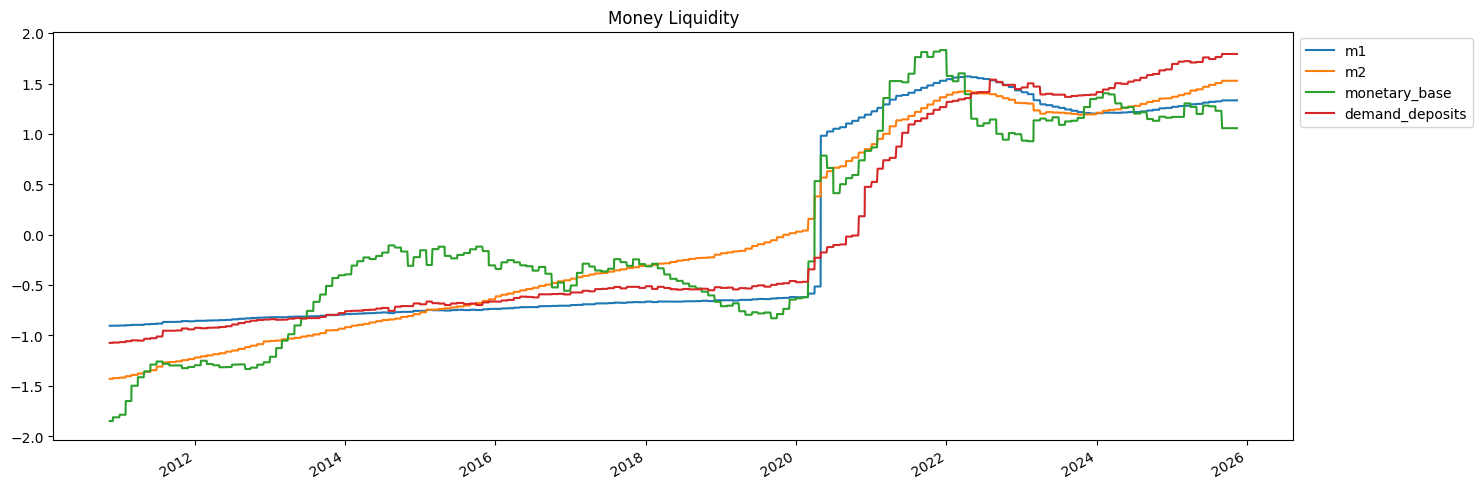

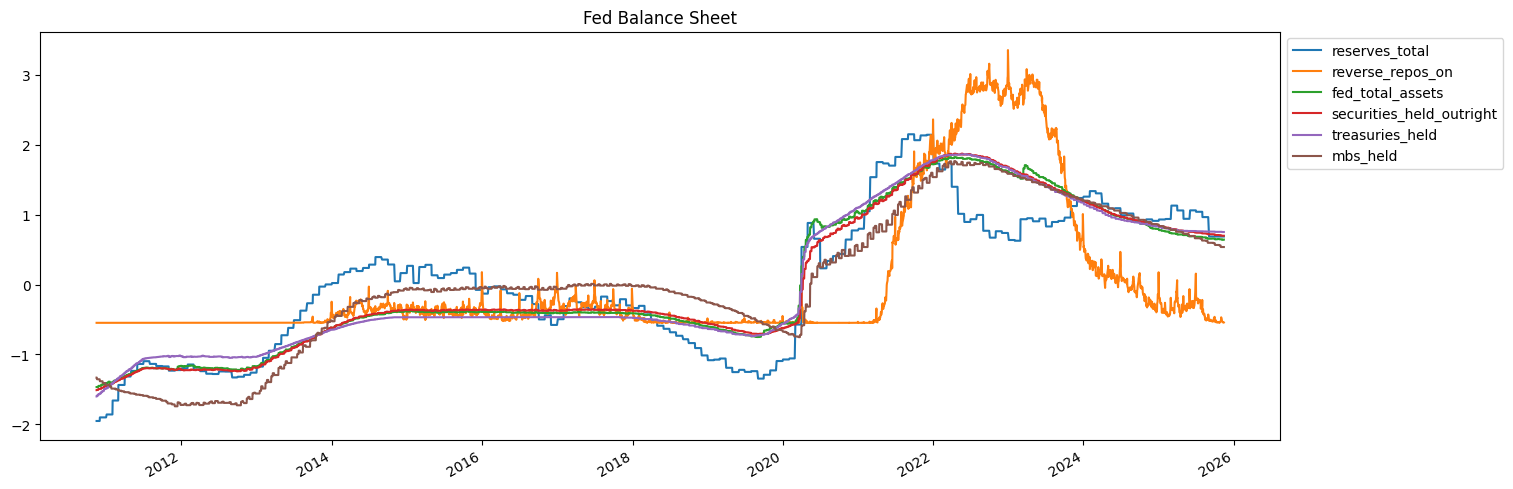

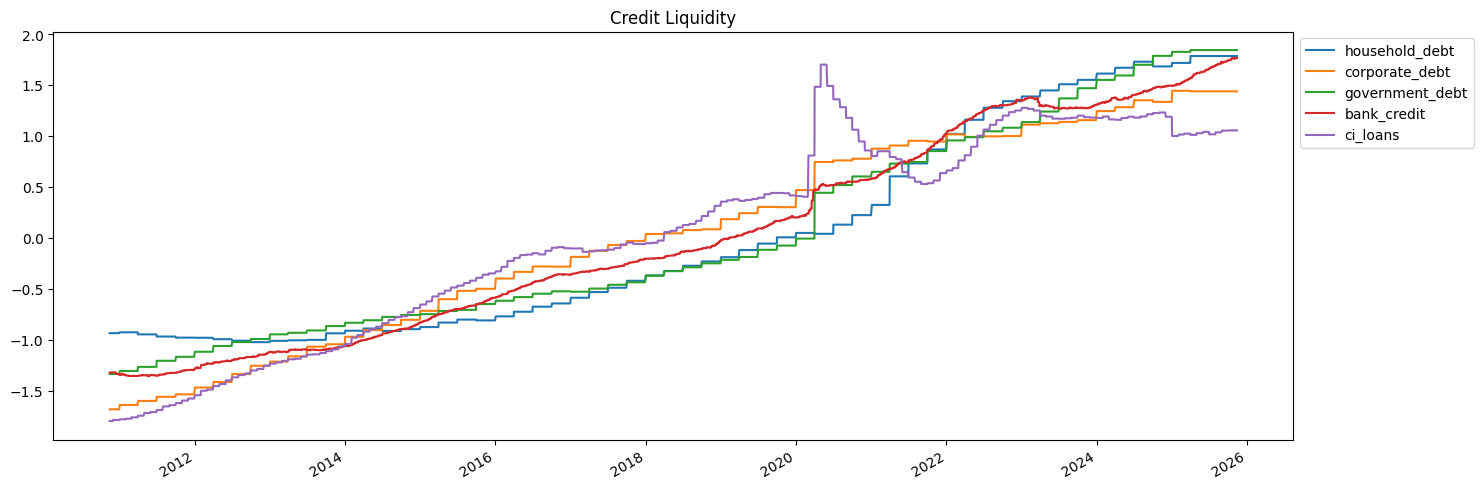

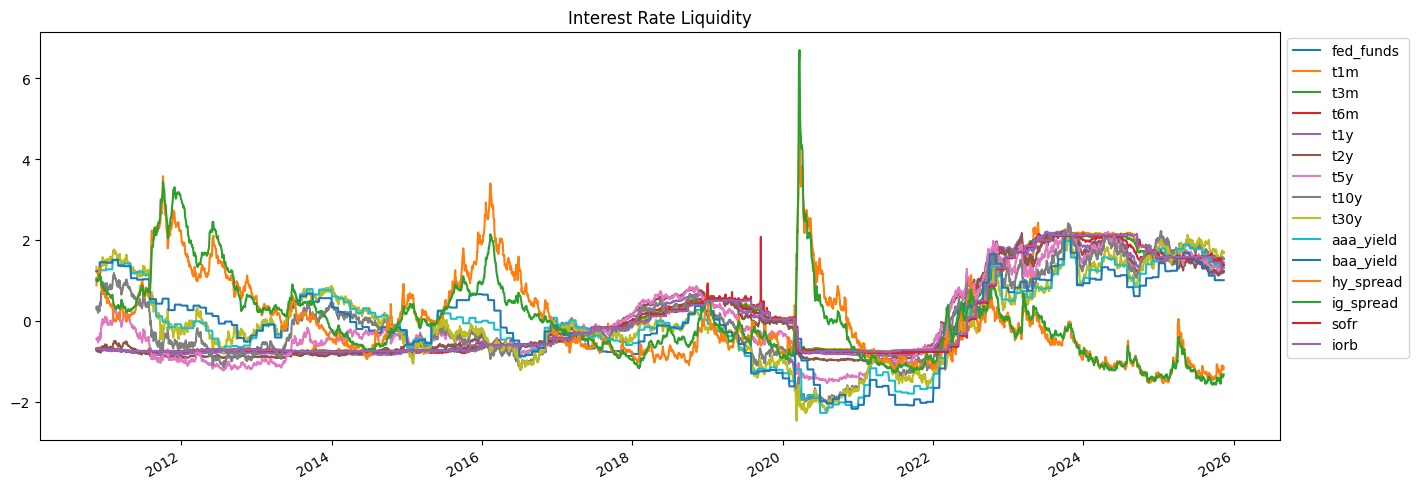

In [40]:
## Plot of liquidity groups 

groups = {
    "Money Liquidity": ['m1','m2','monetary_base','demand_deposits'],
    "Fed Balance Sheet": ['reserves_total','reverse_repos_on','fed_total_assets',
                          'securities_held_outright','treasuries_held','mbs_held'],
    "Credit Liquidity": ['household_debt','corporate_debt','government_debt',
                         'bank_credit','ci_loans'],
    "Interest Rate Liquidity": ['fed_funds','t1m','t3m','t6m','t1y','t2y','t5y',
                                't10y','t30y','aaa_yield','baa_yield',
                                'hy_spread','ig_spread', 'sofr', 'iorb']
}

for name, cols in groups.items():
    df_daily_z_snp[cols].plot(figsize=(16,6), title=name)
    plt.legend(cols, bbox_to_anchor=(1,1))
    plt.show()


In [31]:
import seaborn as sns 

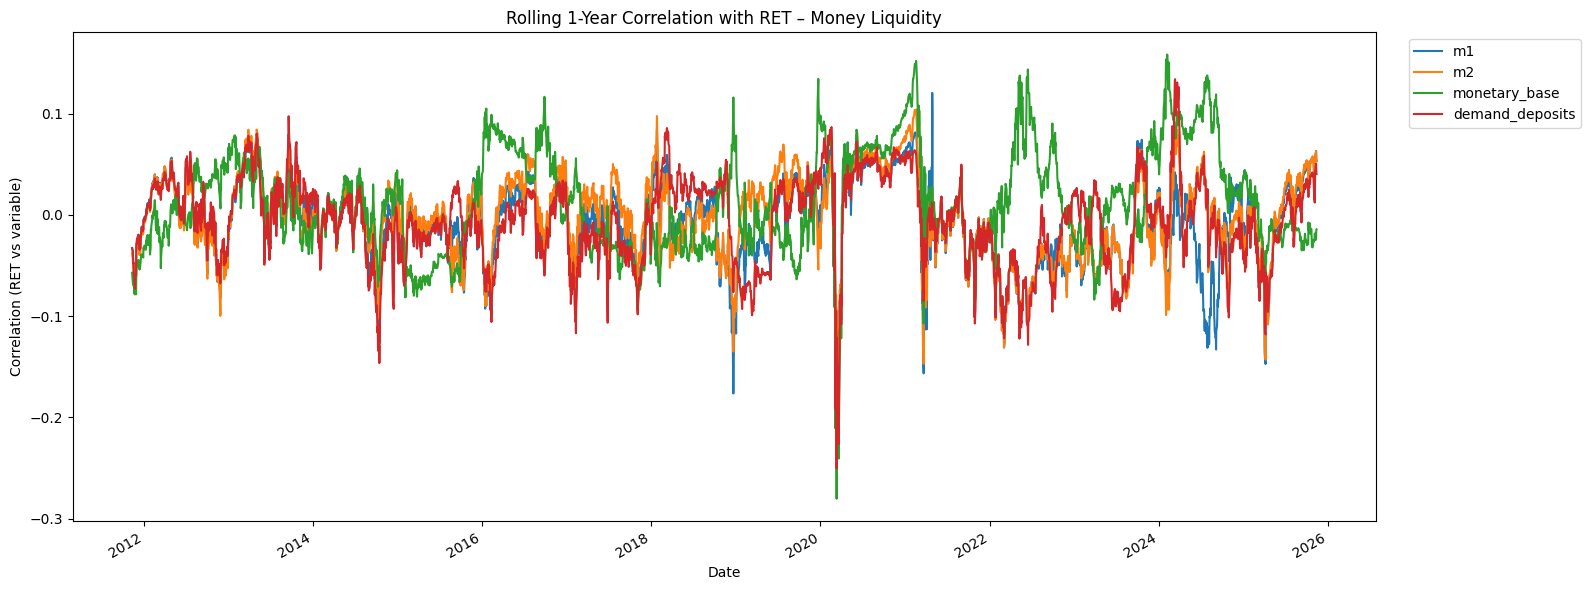

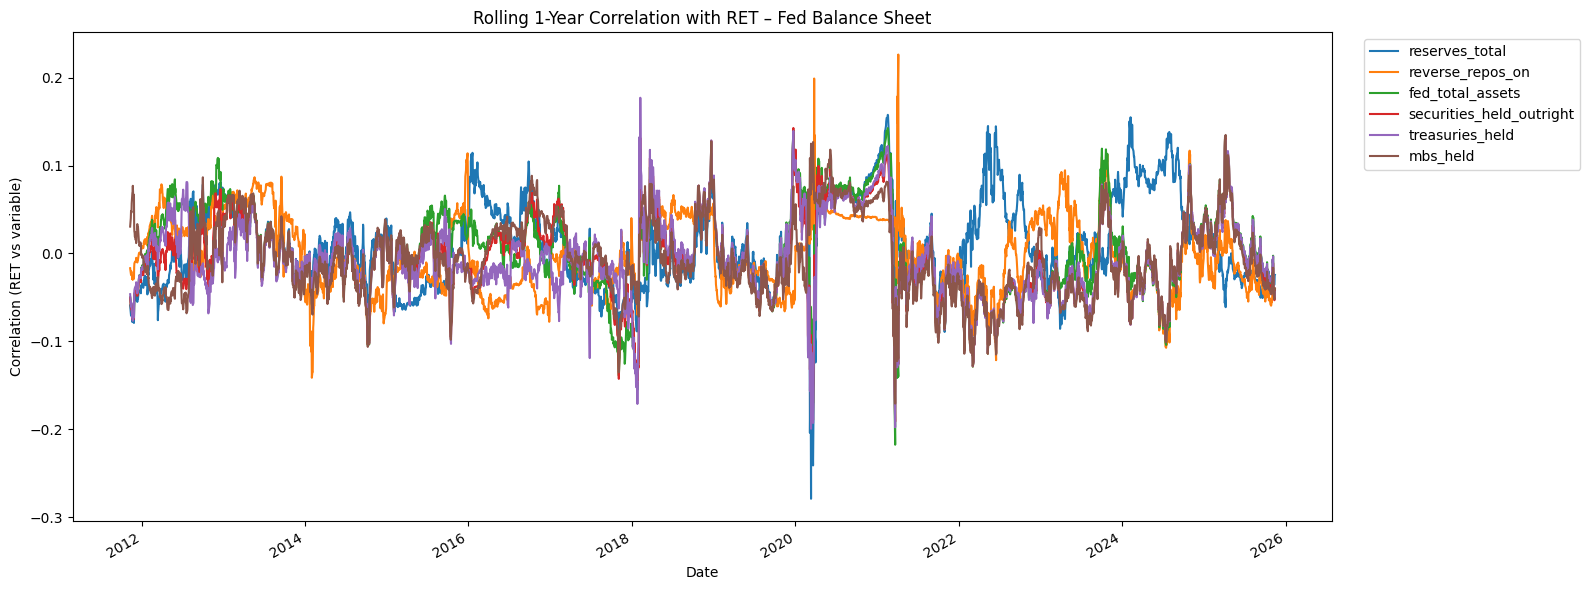

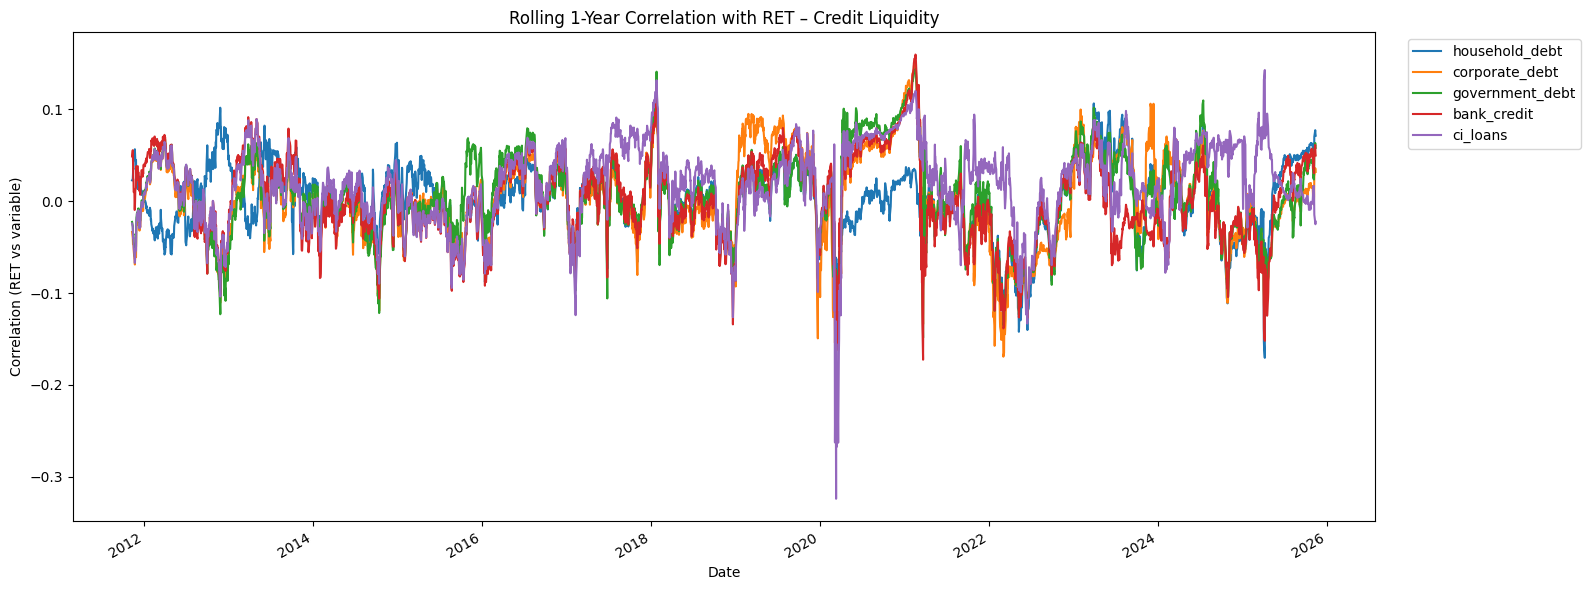

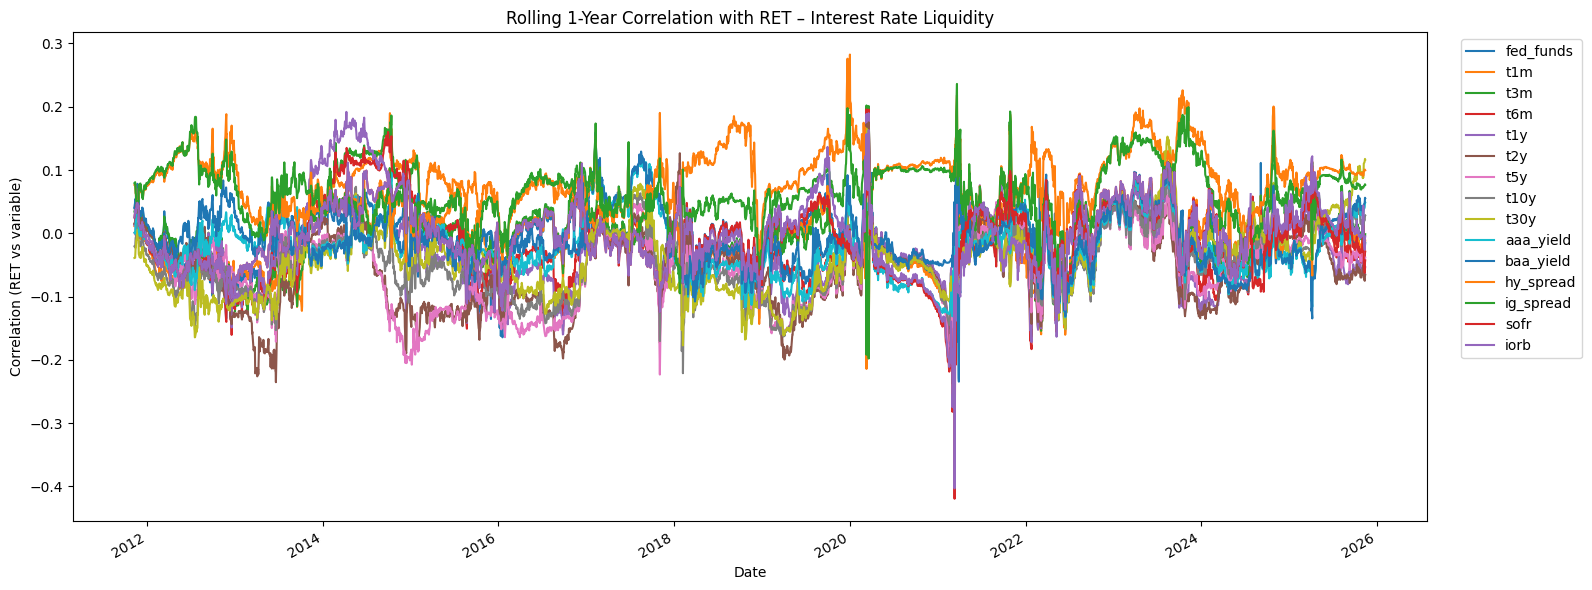

In [ ]:
# ========== Rolling correlation of RET vs every other variable ==========

# --- 1) Rolling correlation  ---

window = 252  # 1-year for daily data

roll_corr = pd.DataFrame(index=df_daily_z_snp.index, columns=df_daily_z_snp.columns)

for col in df_daily_z_snp.columns:
    roll_corr[col] = df_daily_z_snp['RET'].rolling(window).corr(df_daily_z_snp[col])

# Drop the identity (RET with RET = 1)
roll_corr = roll_corr.drop(columns=['RET'])


# --- 2) Plot separate rolling-corr charts per group ---

import matplotlib.pyplot as plt

for name, cols in groups.items():
    # keep only columns that actually exist in roll_corr
    cols_in_data = [c for c in cols if c in roll_corr.columns]
    if not cols_in_data:
        continue  # skip empty groups

    plt.figure(figsize=(16, 6))
    roll_corr[cols_in_data].plot(ax=plt.gca())
    plt.title(f"Rolling 1-Year Correlation with RET – {name}")
    plt.xlabel("Date")
    plt.ylabel("Correlation (RET vs variable)")
    plt.legend(cols_in_data, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [ ]:
# ========== Most meaningful variables ==========

# Full-sample correlation with RET
corr_with_ret = df_daily_z_snp.corr()['RET'].drop(['RET', 'reserves_required'])

# Sort by absolute correlation (strongest first)
corr_ranked = corr_with_ret.reindex(
    corr_with_ret.abs().sort_values(ascending=False).index
)

# Choose top N variables (e.g. 7)
N = 7
key_vars = corr_ranked.head(N).index.tolist()

print("Top variables by absolute correlation with RET:")
print(corr_ranked.head(N))


Top variables by absolute correlation with RET:
hy_spread           0.041052
ig_spread           0.036958
t5y                -0.012375
t10y               -0.012345
reverse_repos_on   -0.012084
ci_loans            0.009809
reserves_total      0.009209
Name: RET, dtype: float64


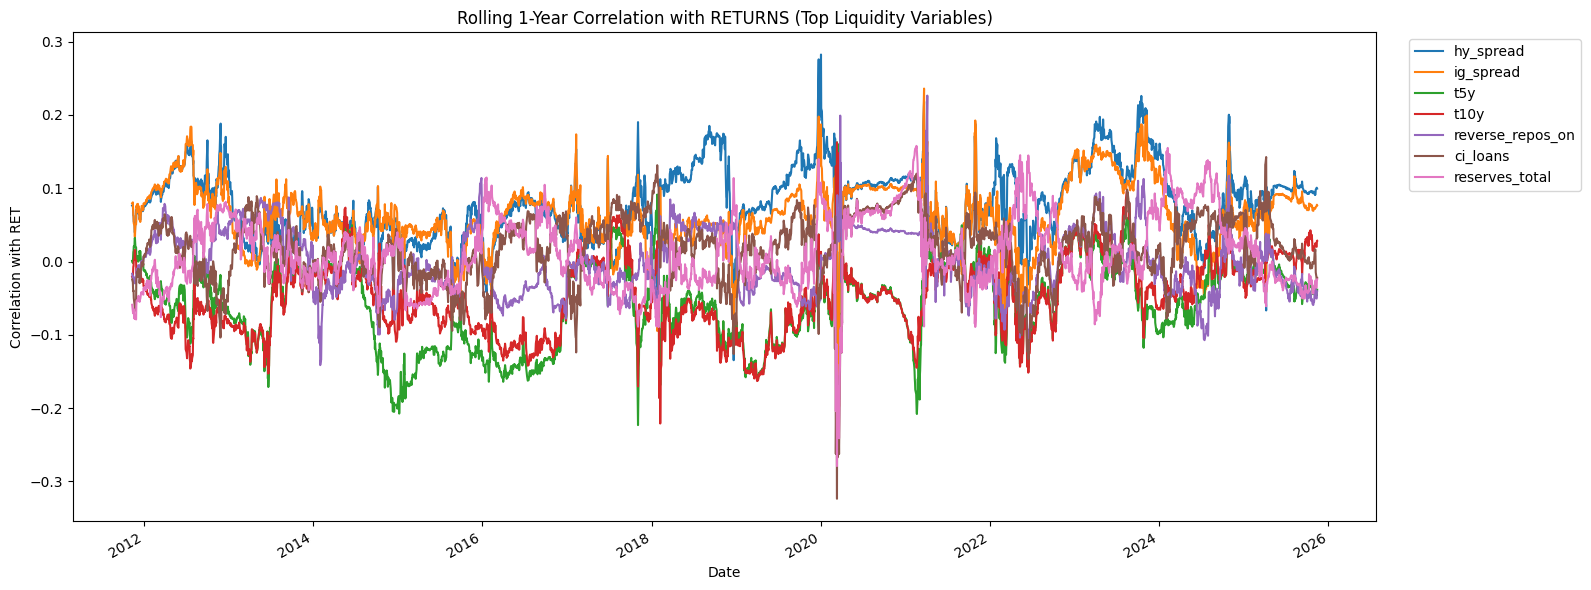

In [44]:
roll_corr[key_vars].plot(figsize=(16, 6))
plt.title("Rolling 1-Year Correlation with RETURNS (Top Liquidity Variables)")
plt.ylabel("Correlation with RET")
plt.xlabel("Date")
plt.legend(key_vars, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Analytics and learning strtaegies : Index construction 

We start with a ridge regression as an initial attempt to construct the index. <br> 
We do a cross validation to asses the accuracy of the sign of return of the snp

In [ ]:
# ------- feature engineering --------

df_snp.index = df_snp.index.tz_localize(None)

df = pd.concat([df_daily_z_snp.dropna(subset=['RET']).copy(), df_snp], axis = 1) 
df['mom_1d'] = df['Close'].pct_change(1)
df['mom_5d'] = df['Close'].pct_change(5)
df['mom_21d'] = df['Close'].pct_change(21)
df['mom_63d'] = df['Close'].pct_change(63)
df['mom_252d'] = df['Close'].pct_change(252)

df['drawdown'] = df['Close'] / df['Close'].cummax() - 1

ret_hist = df['RET'].shift(1)
vol_5  = ret_hist.rolling(5).std()
vol_21  = ret_hist.rolling(21).std()

vol_252 = ret_hist.rolling(252).std()
df['vol_regime'] = (vol_21 > vol_252).astype(int)
df['vol_5d'] = vol_5
df['vol_21d'] = vol_21

df['term_spread'] = df['t10y'] - df['t3m']

df = df.dropna()



In [ ]:
# -------- baseline model vs  with CB data -------

# -------- 0. Prepare X, y --------
feature_cols = [c for c in df.columns if c not in ['RET', 'Close']]
X_full = df[feature_cols].values
y = np.sign(df['RET'].values)
y[y == 0] = 1

# -------- 1. Define central-bank-related features --------
central_bank_features = [
    'm1', 'm2', 'monetary_base', 'demand_deposits',
    'reserves_total', 'reserves_required', 'reverse_repos_on',
    'fed_total_assets', 'securities_held_outright',
    'treasuries_held', 'mbs_held',
    'fed_funds', 'sofr', 'iorb',
    't1m', 't3m', 't6m', 't1y', 't2y', 't5y', 't10y', 't30y',
]

# Baseline features = everything except CB features
baseline_feature_cols = [c for c in feature_cols if c not in central_bank_features]

# For convenience, precompute column indices in X_full
baseline_indices = [feature_cols.index(c) for c in baseline_feature_cols]

# -------- 2. Time-series CV setup --------

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
alpha = 10.0

# Store accuracies
baseline_fold_accuracies = []
full_fold_accuracies = []

# Store coefficients
baseline_coefficients = []  
full_coefficients = []       

baseline_intercepts = []
full_intercepts = []

fold_ids = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full), start=1):
    # Split
    X_train_full, X_test_full = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Baseline model (no CB features) ---
    X_train_base = X_train_full[:, baseline_indices]
    X_test_base  = X_test_full[:, baseline_indices]

    scaler_base = StandardScaler()
    X_train_base_scaled = scaler_base.fit_transform(X_train_base)
    X_test_base_scaled  = scaler_base.transform(X_test_base)

    model_base = Ridge(alpha=alpha)
    model_base.fit(X_train_base_scaled, y_train)

    y_pred_base = model_base.predict(X_test_base_scaled)
    y_pred_base_sign = np.sign(y_pred_base)
    y_pred_base_sign[y_pred_base_sign == 0] = 1

    acc_base = (y_pred_base_sign == y_test).mean()
    baseline_fold_accuracies.append(acc_base)

    baseline_coefficients.append(model_base.coef_)
    baseline_intercepts.append(model_base.intercept_)

    # --- Full model (all features, including CB) ---
    scaler_full = StandardScaler()
    X_train_full_scaled = scaler_full.fit_transform(X_train_full)
    X_test_full_scaled  = scaler_full.transform(X_test_full)

    model_full = Ridge(alpha=alpha)
    model_full.fit(X_train_full_scaled, y_train)

    y_pred_full = model_full.predict(X_test_full_scaled)
    y_pred_full_sign = np.sign(y_pred_full)
    y_pred_full_sign[y_pred_full_sign == 0] = 1

    acc_full = (y_pred_full_sign == y_test).mean()
    full_fold_accuracies.append(acc_full)

    full_coefficients.append(model_full.coef_)
    full_intercepts.append(model_full.intercept_)

    fold_ids.append(fold)

    print(f"Fold {fold}: "
          f"baseline acc = {acc_base:.3f}, "
          f"full acc = {acc_full:.3f}")

# -------- 3. Summary --------

print("\nBaseline accuracies per fold:",
      [f"{a:.3f}" for a in baseline_fold_accuracies])
print("Full-model accuracies per fold:",
      [f"{a:.3f}" for a in full_fold_accuracies])

print(f"\nAverage baseline accuracy: {np.mean(baseline_fold_accuracies):.3f}")
print(f"Average full-model accuracy: {np.mean(full_fold_accuracies):.3f}")

# -------- 4. Coefficient DataFrames --------

baseline_coef_df = pd.DataFrame(baseline_coefficients,
                                columns=baseline_feature_cols)
baseline_coef_df['intercept'] = baseline_intercepts
baseline_coef_df['fold'] = fold_ids

full_coef_df = pd.DataFrame(full_coefficients,
                            columns=feature_cols)
full_coef_df['intercept'] = full_intercepts
full_coef_df['fold'] = fold_ids

print("\nBaseline coefficient matrix by fold:")
display(baseline_coef_df)

print("\nFull-model coefficient matrix by fold:")
display(full_coef_df)


Fold 1: baseline acc = 0.527, full acc = 0.514
Fold 2: baseline acc = 0.536, full acc = 0.497
Fold 3: baseline acc = 0.471, full acc = 0.577
Fold 4: baseline acc = 0.517, full acc = 0.505
Fold 5: baseline acc = 0.432, full acc = 0.515

Baseline accuracies per fold: ['0.527', '0.536', '0.471', '0.517', '0.432']
Full-model accuracies per fold: ['0.514', '0.497', '0.577', '0.505', '0.515']

Average baseline accuracy: 0.497
Average full-model accuracy: 0.522

Baseline coefficient matrix by fold:


,household_debt,corporate_debt,government_debt,bank_credit,ci_loans,aaa_yield,baa_yield,hy_spread,ig_spread,mom_1d,...,mom_21d,mom_63d,mom_252d,drawdown,vol_regime,vol_5d,vol_21d,term_spread,intercept,fold
0,-0.026275,0.141946,-0.104625,-0.053225,0.144544,0.111989,-0.056454,-0.132855,0.232760,-0.020854,...,-0.078101,-0.003013,-0.061924,0.077510,0.094756,0.024738,-0.012387,-0.115870,0.099831,1
1,0.052290,-0.011612,0.114808,-0.148698,-0.062356,0.152393,-0.033218,-0.196552,0.016498,-0.011655,...,0.007588,0.029498,-0.081843,-0.172693,0.111700,0.018818,-0.108484,-0.207065,0.077315,2
2,-0.030420,0.167629,-0.038079,-0.118826,-0.071485,0.196898,-0.172985,-0.052949,0.038140,-0.027370,...,0.002779,0.003554,-0.030747,-0.110542,0.062879,-0.001091,-0.068242,-0.107687,0.079977,3
3,-0.003158,0.025053,0.142010,-0.224941,0.012446,0.307938,-0.299567,0.010540,0.037420,-0.050022,...,0.011625,0.033804,0.004620,-0.189520,0.046782,-0.024612,-0.114467,-0.110375,0.097488,4
4,-0.067396,0.239075,0.133705,-0.432530,-0.015648,0.258599,-0.332106,-0.005483,0.065512,-0.030942,...,0.011798,0.012563,0.039150,-0.220880,0.037695,-0.033384,-0.091036,-0.096204,0.079387,5



Full-model coefficient matrix by fold:


,m1,m2,monetary_base,demand_deposits,reserves_total,reserves_required,reverse_repos_on,fed_total_assets,securities_held_outright,treasuries_held,...,mom_21d,mom_63d,mom_252d,drawdown,vol_regime,vol_5d,vol_21d,term_spread,intercept,fold
0,0.059784,0.157218,0.081348,0.036640,0.070188,0.000000,-0.122706,0.007155,-0.215673,-0.185435,...,-0.109337,-0.021986,-0.143261,0.116233,0.067602,0.025376,0.008442,-0.028929,0.099831,1
1,-0.014039,0.099301,0.000766,-0.057023,-0.047203,0.000000,-0.022982,0.056683,-0.105174,-0.083535,...,0.018528,0.038624,-0.120340,-0.210097,0.123874,0.019970,-0.124864,-0.052775,0.077315,2
2,0.003825,0.154576,0.074473,-0.094975,0.018774,0.000000,0.008938,0.073667,-0.131009,-0.103748,...,0.008927,0.019480,-0.037201,-0.150077,0.071271,0.000443,-0.075743,-0.065842,0.079977,3
3,0.038218,-0.002051,0.022161,-0.032795,0.011780,-0.157659,0.012848,0.043458,-0.138866,-0.215432,...,0.008819,0.036592,-0.003200,-0.214729,0.058634,-0.021435,-0.138573,-0.091482,0.097488,4
4,0.098878,0.019185,0.086512,-0.163773,0.035611,-0.142652,0.035242,-0.019796,-0.191327,-0.268371,...,0.014087,0.011620,0.004269,-0.240655,0.046385,-0.033810,-0.107314,-0.039967,0.079387,5


## Empirical results : baseline and robustness 

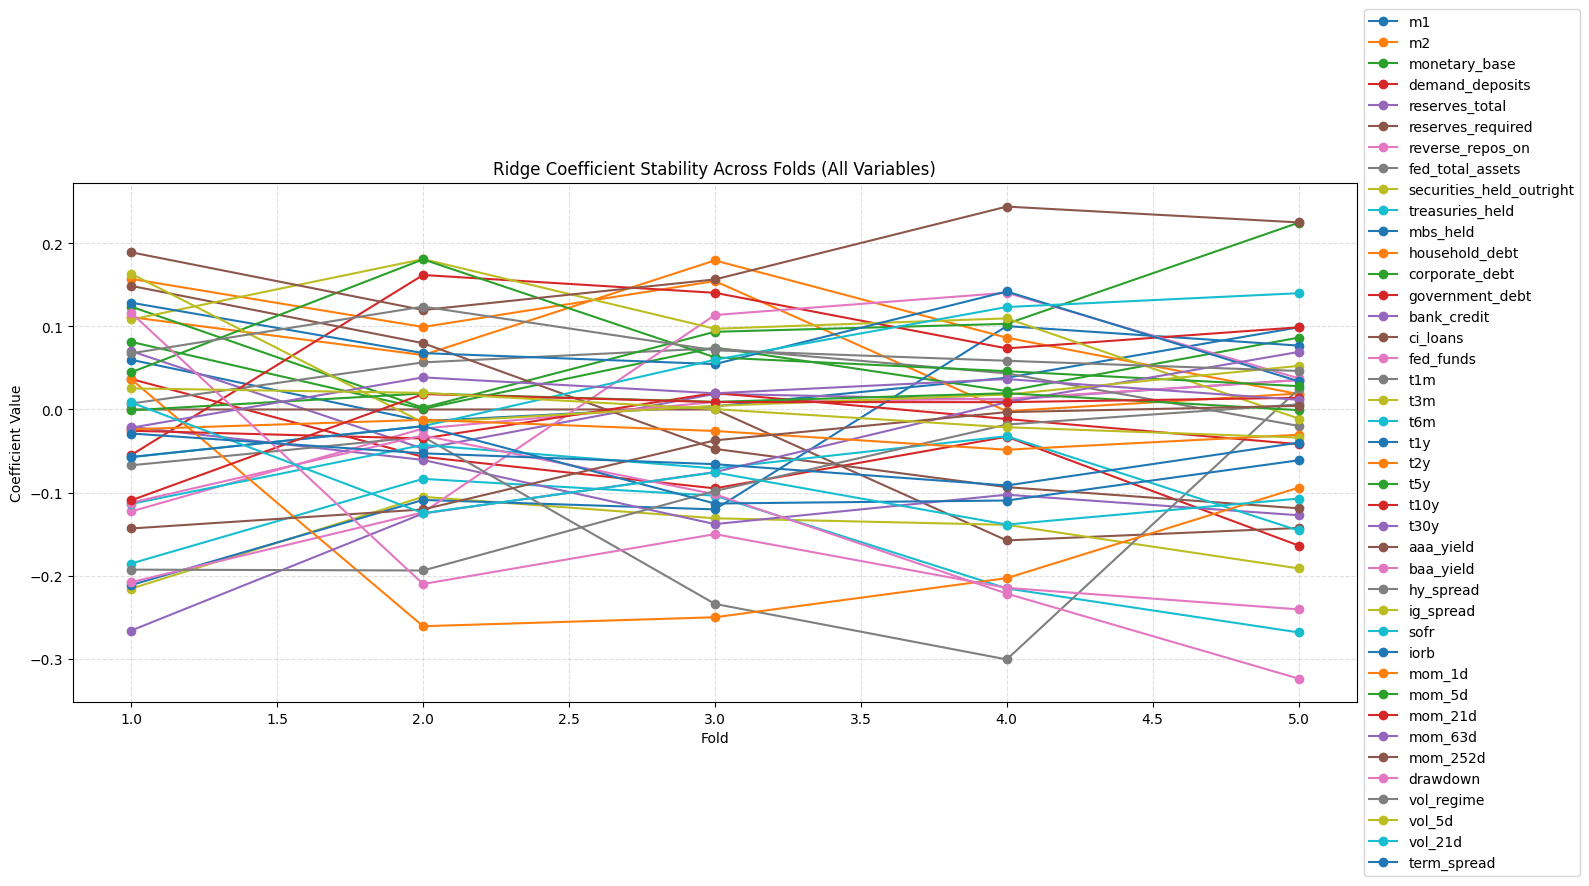

In [ ]:
# --------- ridge coeffs across folds --------

coef_vars = [c for c in full_coef_df.columns if c not in ['fold', 'intercept']]

plt.figure(figsize=(16, 8))

for var in coef_vars:
    plt.plot(full_coef_df['fold'], full_coef_df[var], marker='o', label=var)

plt.title("Ridge Coefficient Stability Across Folds (All Variables)")
plt.xlabel("Fold")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


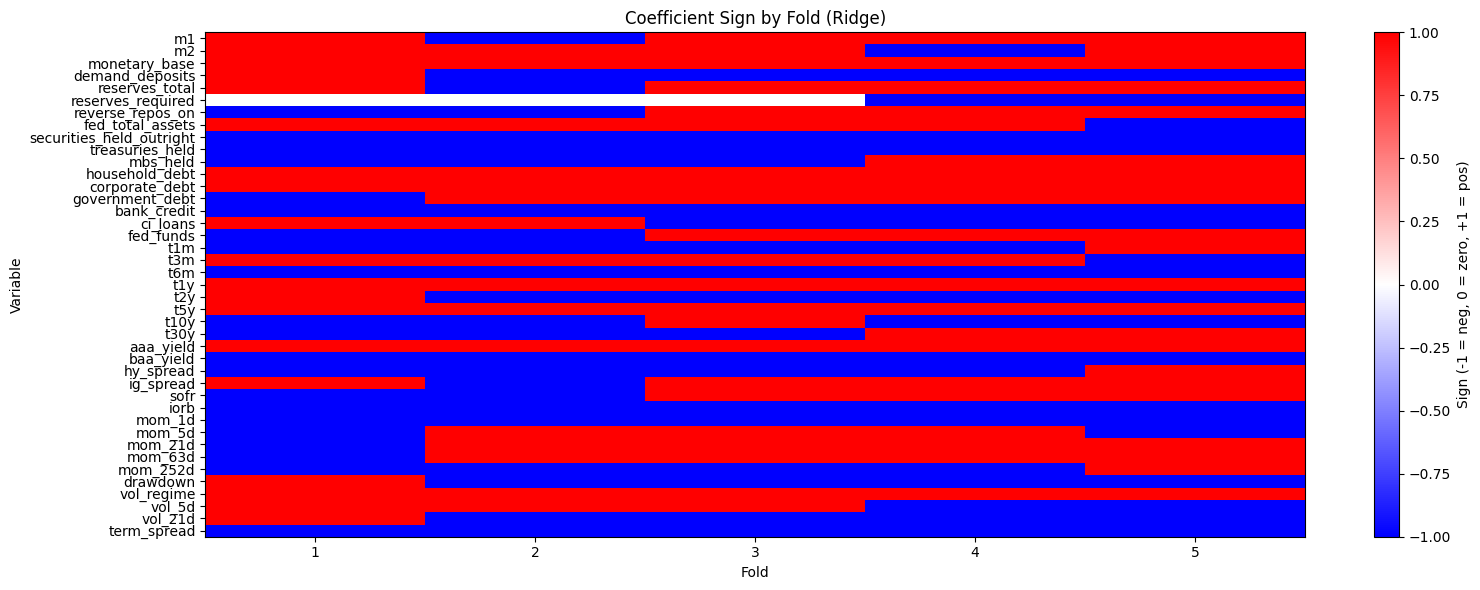

In [ ]:
coef_vars = [c for c in full_coef_df.columns if c not in ['fold', 'intercept']]

# Extract coefficient matrix as (n_folds × n_features)
coef_matrix = full_coef_df[coef_vars].values

# Compute sign of each coefficient: -1, 0, +1
sign_matrix = np.sign(coef_matrix)

sign_df = pd.DataFrame(sign_matrix, columns=coef_vars)
sign_df['fold'] = full_coef_df['fold']

plt.figure(figsize=(16, 6))
plt.imshow(sign_df[coef_vars].T, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(label='Sign (-1 = neg, 0 = zero, +1 = pos)')
plt.yticks(range(len(coef_vars)), coef_vars)
plt.xticks(range(len(sign_df['fold'])), sign_df['fold'])
plt.title("Coefficient Sign by Fold (Ridge)")
plt.xlabel("Fold")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Analysis of variables  with a constant sign across folds 

In [ ]:
# Extract only the sign matrix without the fold column
sign_only = sign_df[coef_vars].values   

# Determine constant-sign variables
constant_positive = []
constant_negative = []
constant_sign = []

for var in coef_vars:
    signs = sign_df[var].values
    unique_signs = np.unique(signs)

    unique_signs = unique_signs[unique_signs != 0]

    if len(unique_signs) == 1:  # only one sign across folds
        constant_sign.append(var)
        if unique_signs[0] == 1:
            constant_positive.append(var)
        elif unique_signs[0] == -1:
            constant_negative.append(var)

print("Variables with constant sign across folds:")
print(constant_sign)

print("\nAlways positive:")
print(constant_positive)

print("\nAlways negative:")
print(constant_negative)


Variables with constant sign across folds:
['monetary_base', 'reserves_required', 'securities_held_outright', 'treasuries_held', 'household_debt', 'corporate_debt', 'bank_credit', 't6m', 't1y', 't5y', 'aaa_yield', 'baa_yield', 'iorb', 'mom_1d', 'vol_regime', 'term_spread']

Always positive:
['monetary_base', 'household_debt', 'corporate_debt', 't1y', 't5y', 'aaa_yield', 'vol_regime']

Always negative:
['reserves_required', 'securities_held_outright', 'treasuries_held', 'bank_credit', 't6m', 'baa_yield', 'iorb', 'mom_1d', 'term_spread']


In [ ]:
def ridge_standard_errors(X, y, alpha, model):
    """
    Compute standard errors for Ridge regression coefficients.
    
    X: scaled design matrix used to fit the model
    y: target vector used to fit the model
    alpha: ridge penalty λ
    model: fitted Ridge model
    """

    n, p = X.shape

    # Predicted values
    y_pred = model.predict(X)
    
    # Residual variance sigma^2
    resid = y - y_pred
    sigma2 = np.sum(resid**2) / (n - p)

    # Covariance matrix of ridge estimator
    XtX = X.T @ X
    A = XtX + alpha * np.eye(p)
    A_inv = np.linalg.inv(A)

    cov_beta = sigma2 * (A_inv @ XtX @ A_inv)

    # Standard errors are sqrt of diagonal
    se = np.sqrt(np.diag(cov_beta))
    return se


In [ ]:
# ---------- ridge with only features keeping a constant sign across folds --------

const_fold_accuracies = []
const_coefficients = []
const_intercepts = []
const_standard_errors = []
const_fold_ids = []

# preallocate liquidity index + signal series (aligned with df)
liq_index_ridge_const = pd.Series(index=df.index, dtype=float)
signal_ridge_const    = pd.Series(index=df.index, dtype=float)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_const), start=1):
    
    X_train, X_test = X_const[train_idx], X_const[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Ridge
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    # Store coefficients
    const_coefficients.append(model.coef_)
    const_intercepts.append(model.intercept_)

    # Compute standard errors
    se = ridge_standard_errors(X_train_scaled, y_train, alpha, model)
    const_standard_errors.append(se)

    # ---------- NEW: construct liquidity index & trading signal on TEST window ----------
    # Liquidity index = β' x_t (on scaled features)
    liq_idx_test = X_test_scaled @ model.coef_
    liq_index_ridge_const.iloc[test_idx] = liq_idx_test

    # Predicted sign (signal)
    y_pred = model.predict(X_test_scaled)
    y_pred_sign = np.sign(y_pred)
    y_pred_sign[y_pred_sign == 0] = 1
    signal_ridge_const.iloc[test_idx] = y_pred_sign
    # -------------------------------------------------------------------------------

    # Evaluate
    acc = (y_pred_sign == y_test).mean()
    const_fold_accuracies.append(acc)
    const_fold_ids.append(fold)

    print(f"Fold {fold}: accuracy = {acc:.3f}")

const_coef_df = pd.DataFrame(const_coefficients, columns=const_feature_cols)
const_coef_df['intercept'] = const_intercepts
const_coef_df['fold'] = const_fold_ids

const_se_df = pd.DataFrame(const_standard_errors, columns=const_feature_cols)
const_se_df['fold'] = const_fold_ids

# Summary
overall_const_acc = np.mean(const_fold_accuracies)
print("\nPer-fold accuracies (constant-sign features):",
      [f"{a:.3f}" for a in const_fold_accuracies])
print(f"Average accuracy over {n_splits} folds (constant-sign features): {overall_const_acc:.3f}")

print("\nConstant-sign model coefficient matrix by fold:")
display(const_coef_df)

df['LIQ_RIDGE_CONST'] = liq_index_ridge_const
df['SIGNAL_RIDGE_CONST'] = signal_ridge_const


Fold 1: accuracy = 0.514
Fold 2: accuracy = 0.549
Fold 3: accuracy = 0.572
Fold 4: accuracy = 0.502
Fold 5: accuracy = 0.572

Per-fold accuracies (constant-sign features): ['0.514', '0.549', '0.572', '0.502', '0.572']
Average accuracy over 5 folds (constant-sign features): 0.542

Constant-sign model coefficient matrix by fold:


,monetary_base,reserves_required,securities_held_outright,treasuries_held,household_debt,corporate_debt,bank_credit,t6m,t1y,t5y,aaa_yield,baa_yield,iorb,mom_1d,vol_regime,term_spread,intercept,fold
0,0.195074,0.000000,-0.211673,-0.190384,0.064626,0.131084,0.038470,-0.137875,0.169123,0.053547,0.204098,-0.044478,-0.109491,-0.026209,0.093994,-0.281640,0.099831,1
1,0.108009,0.000000,-0.096309,-0.083265,0.097694,0.053483,-0.109330,0.028614,-0.067291,0.044321,0.238592,-0.102358,-0.009141,-0.034313,0.081738,-0.229171,0.077315,2
2,0.069355,0.000000,-0.123361,-0.035551,0.253001,0.092611,-0.162132,-0.140173,-0.036891,0.035843,0.213321,-0.124741,-0.051098,-0.044792,0.062549,-0.168604,0.079977,3
3,0.024105,-0.162308,0.027689,-0.149724,0.022025,0.087647,-0.155040,-0.060333,0.056076,0.004288,0.310547,-0.193311,-0.021243,-0.067065,0.044052,-0.184615,0.097488,4
4,0.065677,-0.181224,-0.065666,-0.163036,0.020444,0.104593,-0.180265,-0.057677,-0.018209,0.004942,0.227501,-0.186522,0.055367,-0.051657,0.036414,-0.101717,0.079387,5


In [ ]:
# ----------- Coeffs with their standard errors --------

output_notebook()

folds = const_coef_df['fold'].values

n_vars = len(const_feature_cols)
palette = Category10[10] if n_vars <= 10 else Category20[20]

p = figure(
    width=950,
    height=550,
    title="Ridge Coefficient Stability Across Folds (with 95% Confidence Bands)",
    x_axis_label="Fold",
    y_axis_label="Coefficient Value",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

legend_items = []   

for i, var in enumerate(const_feature_cols):
    color = palette[i % len(palette)]

    betas = const_coef_df[var].values
    ses   = const_se_df[var].values

    lower = betas - 1.96 * ses
    upper = betas + 1.96 * ses

    source = ColumnDataSource(data={
        "fold": folds,
        "beta": betas,
        "lower": lower,
        "upper": upper,
        "var": [var] * len(folds),
    })

    # --- Confidence band ---
    band = p.varea(
        x="fold",
        y1="lower",
        y2="upper",
        source=source,
        fill_alpha=0.15,
        fill_color=color,
    )

    # --- Coefficient line ---
    line = p.line(
        x="fold",
        y="beta",
        source=source,
        line_width=2,
        line_color=color,
    )

    circle = p.circle(
        x="fold",
        y="beta",
        source=source,
        size=6,
        fill_color=color,
        line_color=color,
    )

    legend_items.append(
        LegendItem(label=var, renderers=[line, circle, band])
    )

legend = Legend(
    items=legend_items,
    location="center",
    click_policy="hide",
)

p.add_layout(legend, 'right')

hover = HoverTool(
    tooltips=[
        ("Variable", "@var"),
        ("Fold", "@fold"),
        ("β", "@beta{0.0000}"),
        ("Lower 95%", "@lower{0.0000}"),
        ("Upper 95%", "@upper{0.0000}")
    ],
    mode="mouse",
    renderers=[item.renderers[0] for item in legend_items],  # only lines
)
p.add_tools(hover)

show(p)


Loading BokehJS ...

** Coefficients interpretation 

- Monetary base : positive coefficient <br>
--> injections of money immediately support risk taking and equity prices <br>
- Securities held outright and treasuries held : negative coefficient <br>
--> During periods of panic, the Fed expands its balance sheets, equity markets may continue falling <br>
- household and corporate debt : positive coefficients <br>
--> rising borrowing by households and firms indicate strong consumption and ivestment demand --> Higher spending / profits / risk appetite <br>
- Bank credit : negative coefficient <br>
--> Borrowing by the banking system indicate excess leverage, tightening funding conditions and future market stress <br>
- Term spread : negative coefficient <br>
--> falling or invertied yield curve predicts a worsening economic expectations <br>
- Long term yields : near zero coefficients <br>
--> Long maturities add almost no daily predictive power <br>
- aaa_yield / baa_yield : positive coefficient for aaa and negative for baa <br>
--> rising aaa yields indicate stronger growth expectations while baa indicate credit stress 

## Backtesting 

In [93]:
strategy_ret_const = df['SIGNAL_RIDGE_CONST'] * df['RET']
strategy_ret_const = strategy_ret_const.dropna()

# Cumulative PnL (starting at 1.0)
cum_pnl_const = (1 + strategy_ret_const).cumprod()

final_pnl_const = cum_pnl_const.iloc[-1] - 1

# Annualized Sharpe (252 trading days)
sharpe_const = np.sqrt(252) * strategy_ret_const.mean() / strategy_ret_const.std()

print("\n====== Ridge Liquidity Index (constant-sign features) Backtest ======")
print(f"Final PnL of strategy: {final_pnl_const:.3f}")
print(f"Annualized Sharpe ratio: {sharpe_const:.3f}")


====== Ridge Liquidity Index (constant-sign features) Backtest ======
Final PnL of strategy: 2.230
Annualized Sharpe ratio: 0.661


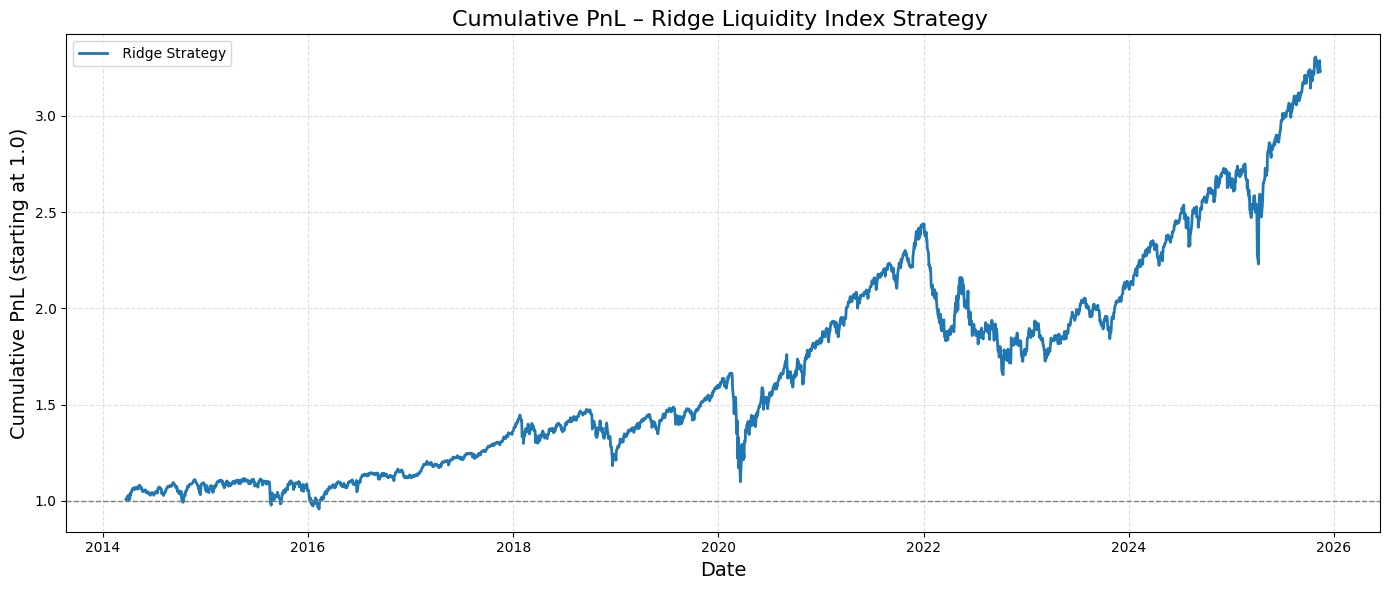

In [96]:
# --------- pnl plot ----------

plt.figure(figsize=(14,6))
plt.plot(cum_pnl_const.index, cum_pnl_const, label=" Ridge Strategy", linewidth=2)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title("Cumulative PnL – Ridge Liquidity Index Strategy ", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative PnL (starting at 1.0)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# Conclusion 

This project set out to see whether Fed data could add meaningful information to predicting the daily direction of the S&P 500, compared with using only basic price-based features. The results show that a handful of Fed variables consistently help the model and come with coefficient signs that make intuitive economic sense. Using these stable predictors, we built a liquidity index that captures day-to-day funding conditions and can easily be combined with other macro indicators, such as an inflation index, in a broader strategy.

With an out-of-sample Sharpe ratio of about 0.66, the signal is far from perfect but clearly useful. It suggests that liquidity conditions do leave a measurable footprint in short-term equity behavior, and that this information can be incorporated into a practical trading or regime-detection framework.